# Precision Comparison Experiment
This notebook compares FP32, FP16, and AMP for medical image classification.

In [1]:
import sys
import os
sys.path.append('.')
from src.dataset import get_dataloaders
from src.model import get_model
from src.train import train_model
from src.utils import set_seed
import matplotlib.pyplot as plt
import pandas as pd
import torch
import numpy as np
import torchvision.transforms as transforms

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

EPOCHS = 5
BATCH_SIZE = 32
LR = 1e-4

IMAGE_PATH = 'E:/'
TRAIN_CSV = 'E:/covidx/covidx_merged.csv'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

results = {}

Using device: cuda


In [2]:
# FP32 Training
set_seed(42)
train_loader, val_loader, test_loader = get_dataloaders(
    csv_file=TRAIN_CSV, 
    root_dir=IMAGE_PATH, 
    batch_size=BATCH_SIZE, 
    transform=transform
)
model_fp32 = get_model(num_classes=2, pretrained=True)
print("\n--- Starting FP32 Training ---")
model_fp32, history_fp32, peak_mem_fp32 = train_model(
    model_fp32, train_loader, val_loader, 
    precision='fp32', epochs=EPOCHS, lr=LR, device=device
)
results['fp32'] = {'history': history_fp32, 'peak_memory': peak_mem_fp32}

2026-02-28 17:01:14,211 - src.dataset - INFO - Original samples: 67863
2026-02-28 17:01:14,212 - src.dataset - INFO - Valid AP/PA samples: 53691
2026-02-28 17:01:14,218 - src.dataset - INFO - Loaded 53691 samples for split 'train'
2026-02-28 17:01:14,226 - src.dataset - INFO - Class distribution: PA=20388, AP=33303
2026-02-28 17:01:14,353 - src.dataset - INFO - Original samples: 8473
2026-02-28 17:01:14,353 - src.dataset - INFO - Valid AP/PA samples: 4186
2026-02-28 17:01:14,354 - src.dataset - INFO - Loaded 4186 samples for split 'val'
2026-02-28 17:01:14,356 - src.dataset - INFO - Class distribution: PA=1275, AP=2911
2026-02-28 17:01:14,482 - src.dataset - INFO - Original samples: 8482
2026-02-28 17:01:14,483 - src.dataset - INFO - Valid AP/PA samples: 7143
2026-02-28 17:01:14,484 - src.dataset - INFO - Loaded 7143 samples for split 'test'
2026-02-28 17:01:14,485 - src.dataset - INFO - Class distribution: PA=3406, AP=3737

--- Starting FP32 Training ---


Epoch 1/5 [Eval]: 100%|██████████| 131/131 [00:18<00:00,  7.19it/s]

2026-02-28 17:05:02,283 - src.train - INFO - Epoch 1/5 - Train Loss: 0.0964 - Val Loss: 0.1288 - Val AUC: 0.9909 - Time: 227.48s



Epoch 2/5 [Eval]: 100%|██████████| 131/131 [00:18<00:00,  7.22it/s]

2026-02-28 17:08:47,183 - src.train - INFO - Epoch 2/5 - Train Loss: 0.0414 - Val Loss: 0.1018 - Val AUC: 0.9933 - Time: 224.90s


...

2026-02-28 17:12:32,055 - src.train - INFO - Epoch 3/5 - Train Loss: 0.0192 - Val Loss: 0.1066 - Val AUC: 0.9939 - Time: 224.87s



Epoch 4/5 [Eval]: 100%|██████████| 131/131 [00:18<00:00,  7.22it/s]

2026-02-28 17:16:16,101 - src.train - INFO - Epoch 4/5 - Train Loss: 0.0056 - Val Loss: 0.1579 - Val AUC: 0.9927 - Time: 224.05s



Epoch 5/5 [Eval]: 100%|██████████| 131/131 [00:18<00:00,  7.21it/s]

2026-02-28 17:20:00,163 - src.train - INFO - Epoch 5/5 - Train Loss: 0.0010 - Val Loss: 0.1465 - Val AUC: 0.9940 - Time: 224.06s
2026-02-28 17:20:00,164 - src.train - INFO - Peak GPU Memory for fp32: 2955.80 MB


In [3]:
# FP16 (Pure) Training
set_seed(42)
model_fp16 = get_model(num_classes=2, pretrained=True)
print("\n--- Starting Pure FP16 Training ---")
model_fp16, history_fp16, peak_mem_fp16 = train_model(
    model_fp16, train_loader, val_loader, 
    precision='fp16', epochs=EPOCHS, lr=LR, device=device
)
results['fp16'] = {'history': history_fp16, 'peak_memory': peak_mem_fp16}


--- Starting Pure FP16 Training ---


Epoch 1/5 [Eval]: 100%|██████████| 131/131 [00:17<00:00,  7.34it/s]

2026-02-28 17:22:22,828 - src.train - INFO - Epoch 1/5 - Train Loss: nan - Val Loss: nan - Val AUC: nan - Time: 142.39s



Epoch 2/5 [Eval]: 100%|██████████| 131/131 [00:17<00:00,  7.38it/s]

2026-02-28 17:24:44,560 - src.train - INFO - Epoch 2/5 - Train Loss: nan - Val Loss: nan - Val AUC: nan - Time: 141.73s


...

2026-02-28 17:27:06,749 - src.train - INFO - Epoch 3/5 - Train Loss: nan - Val Loss: nan - Val AUC: nan - Time: 142.19s



Epoch 4/5 [Eval]: 100%|██████████| 131/131 [00:17<00:00,  7.35it/s]

2026-02-28 17:29:28,393 - src.train - INFO - Epoch 4/5 - Train Loss: nan - Val Loss: nan - Val AUC: nan - Time: 141.64s



Epoch 5/5 [Eval]: 100%|██████████| 131/131 [00:17<00:00,  7.35it/s]

2026-02-28 17:31:50,381 - src.train - INFO - Epoch 5/5 - Train Loss: nan - Val Loss: nan - Val AUC: nan - Time: 141.99s
2026-02-28 17:31:50,381 - src.train - INFO - Peak GPU Memory for fp16: 1729.32 MB


In [4]:
# AMP Training
set_seed(42)
model_amp = get_model(num_classes=2, pretrained=True)
print("\n--- Starting AMP Training ---")
model_amp, history_amp, peak_mem_amp = train_model(
    model_amp, train_loader, val_loader, 
    precision='amp', epochs=EPOCHS, lr=LR, device=device
)
results['amp'] = {'history': history_amp, 'peak_memory': peak_mem_amp}

d:\Projects\ML_Algorithms\float_comparison_dl\src\train.py:107: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if precision == 'amp' else None



--- Starting AMP Training ---


Epoch 1/5 [Eval]: 100%|██████████| 131/131 [00:17<00:00,  7.34it/s]

2026-02-28 17:34:09,671 - src.train - INFO - Epoch 1/5 - Train Loss: 0.0957 - Val Loss: 0.1328 - Val AUC: 0.9900 - Time: 139.05s



Epoch 2/5 [Eval]: 100%|██████████| 131/131 [00:18<00:00,  7.22it/s]

...

2026-02-28 17:38:52,225 - src.train - INFO - Epoch 3/5 - Train Loss: 0.0193 - Val Loss: 0.0983 - Val AUC: 0.9934 - Time: 140.99s



Epoch 4/5 [Eval]: 100%|██████████| 131/131 [00:17<00:00,  7.32it/s]

2026-02-28 17:41:12,091 - src.train - INFO - Epoch 4/5 - Train Loss: 0.0067 - Val Loss: 0.1312 - Val AUC: 0.9938 - Time: 139.87s



Epoch 5/5 [Eval]: 100%|██████████| 131/131 [00:17<00:00,  7.33it/s]

2026-02-28 17:43:32,176 - src.train - INFO - Epoch 5/5 - Train Loss: 0.0013 - Val Loss: 0.1374 - Val AUC: 0.9935 - Time: 140.08s
2026-02-28 17:43:32,177 - src.train - INFO - Peak GPU Memory for amp: 2003.46 MB


,Precision,Avg Time/Epoch (s),Total Time (s),Peak Memory (MB),Final Val Acc,Final Val AUC,Final Val F1
0,FP32,225.072235,1125.361176,2955.795898,0.970139,0.994028,0.965067
1,FP16,141.988765,709.943825,1729.317383,0.695413,NaN,0.410173
2,AMP,140.310193,701.550967,2003.462891,0.972050,0.993512,0.967247


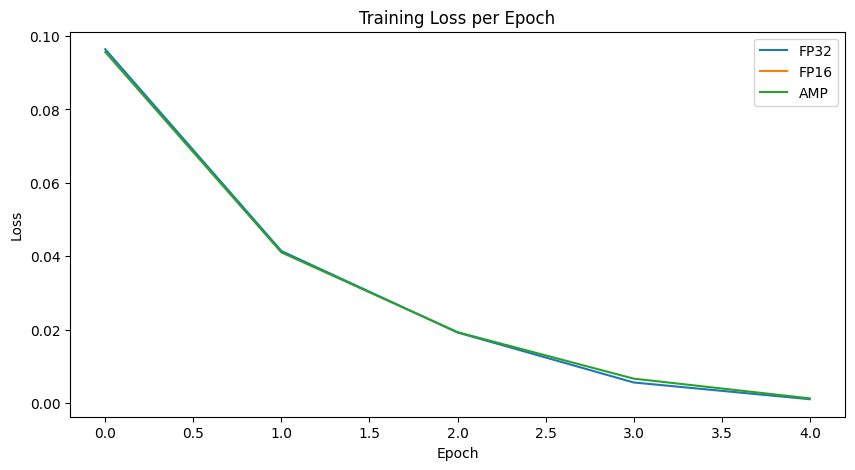

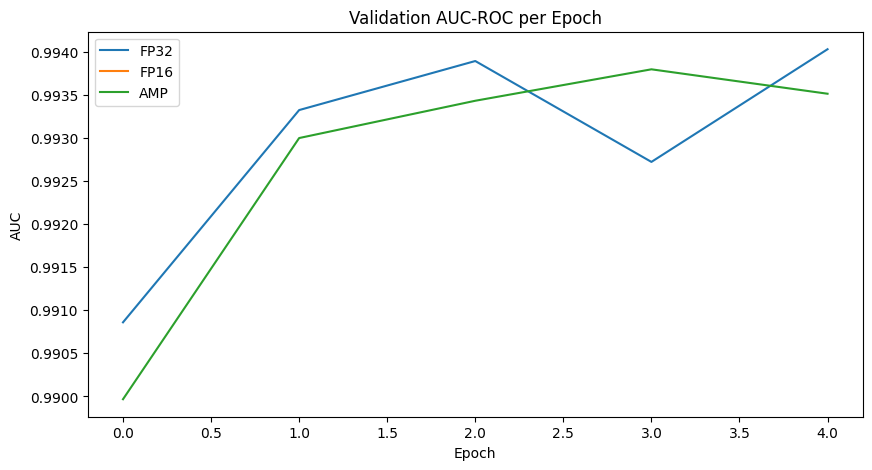

In [5]:
# Visualization and Results
summary = []
for precision in ['fp32', 'fp16', 'amp']:
    h = results[precision]['history']
    summary.append({
        'Precision': precision.upper(),
        'Avg Time/Epoch (s)': sum(h['epoch_times'])/len(h['epoch_times']),
        'Total Time (s)': sum(h['epoch_times']),
        'Peak Memory (MB)': results[precision]['peak_memory'],
        'Final Val Acc': h['val_acc'][-1],
        'Final Val AUC': h['val_auc'][-1],
        'Final Val F1': h['val_f1'][-1]
    })

df = pd.DataFrame(summary)
display(df)
df.to_csv('results_summary.csv', index=False)

plt.figure(figsize=(10, 5))
for p in ['fp32', 'fp16', 'amp']:
    plt.plot(results[p]['history']['train_loss'], label=p.upper())
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('train_loss.png')
plt.show()

plt.figure(figsize=(10, 5))
for p in ['fp32', 'fp16', 'amp']:
    plt.plot(results[p]['history']['val_auc'], label=p.upper())
plt.title('Validation AUC-ROC per Epoch')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.savefig('val_auc.png')
plt.show()